In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.kinematic_vocabulary import KinematicVocabulary
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_model
from src_final.models.analysis import NestedFeatureSelector

Load data and extract window features

In [103]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=True)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:22<00:00,  1.01it/s]


In [104]:
df_pc1_features = pd.read_csv("data/metrics/global_pc1_features.csv")
df_pc1_features['video_id'] = df_window_features['video_id'].unique()

### **Start With Leaky Version Where the Clustering is Fitted on the Entire Data**

In [119]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df_window = df_window_features.copy()

In [120]:
# intercorrelation of features
feature_cols = [col for col in df_window.columns if col not in ['video_id', 'participant_id', 'window_start_frame', 'is_idle']]
corr_matrix = df_window[feature_cols].corr()
corr_matrix

# => vel_p90 is redundant with total_path

,total_path,path_ratio,spatial_spread,zvr,sparc,vel_p90,palm_area_cv,bimanual_dist_mean,bimanual_dist_std,bimanual_sync,bimanual_ratio
total_path,1.000000,0.122232,0.825992,-0.422739,0.133147,0.924942,0.367741,0.079642,0.601078,0.147294,0.266594
path_ratio,0.122232,1.000000,-0.174740,-0.177444,-0.189357,0.006378,0.214029,-0.007202,-0.156325,-0.160431,0.243349
spatial_spread,0.825992,-0.174740,1.000000,-0.243006,0.301928,0.852351,0.156819,0.086533,0.708893,0.260708,0.049463
zvr,-0.422739,-0.177444,-0.243006,1.000000,0.169219,-0.277977,-0.338107,0.001180,-0.170374,0.067228,-0.233254
sparc,0.133147,-0.189357,0.301928,0.169219,1.000000,0.246783,-0.079093,0.055297,0.230202,0.167406,-0.071278
vel_p90,0.924942,0.006378,0.852351,-0.277977,0.246783,1.000000,0.277944,0.080546,0.644024,0.226803,0.207458
palm_area_cv,0.367741,0.214029,0.156819,-0.338107,-0.079093,0.277944,1.000000,-0.107389,0.140952,-0.053842,0.204256
bimanual_dist_mean,0.079642,-0.007202,0.086533,0.001180,0.055297,0.080546,-0.107389,1.000000,0.073847,-0.053180,0.165483
bimanual_dist_std,0.601078,-0.156325,0.708893,-0.170374,0.230202,0.644024,0.140952,0.073847,1.000000,0.164019,-0.163468
bimanual_sync,0.147294,-0.160431,0.260708,0.067228,0.167406,0.226803,-0.053842,-0.053180,0.164019,1.000000,-0.162992


In [ ]:
vocab = KinematicVocabulary(n_clusters=16, random_state=42, model_type='kmeans', n_init=5,
                          feature_cols=['vel_p90', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                          log_feats=['vel_p90', 'path_ratio', 'spatial_spread', 'sparc'])

"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
vocab = KinematicVocabulary(n_clusters=20, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'bimanual_dist_mean', 'bimanual_sync'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])
df_window = df_bimanual.copy()"""

vocab.fit(df_window)
df_voc = vocab.transform(df_window)
df_voc.head(5)


,SurgeMe_0,SurgeMe_1,SurgeMe_2,SurgeMe_3,SurgeMe_4,SurgeMe_5,SurgeMe_6,SurgeMe_7,SurgeMe_8,SurgeMe_9,SurgeMe_10,SurgeMe_11,SurgeMe_12,SurgeMe_13,SurgeMe_14,SurgeMe_15,SurgeMe_16,SurgeMe_17,SurgeMe_18,SurgeMe_19
"(2024-01-15_13-18-23, 1)",0.058699,0.041626,0.040931,0.045760,0.060800,0.038480,0.061176,0.069289,0.055233,0.067551,0.049299,0.028476,0.043086,0.035460,0.058280,0.032867,0.072770,0.037044,0.055710,0.047465
"(2024-01-15_13-37-36, 1)",0.039917,0.046004,0.067577,0.058049,0.068002,0.029576,0.063349,0.040875,0.056705,0.053786,0.064639,0.046623,0.037615,0.046592,0.043838,0.030232,0.066811,0.037831,0.046358,0.055619
"(2024-01-15_14-03-23, 1)",0.042184,0.058457,0.051365,0.043623,0.050899,0.049787,0.053535,0.040140,0.060101,0.054460,0.052368,0.036858,0.042857,0.039425,0.065737,0.054158,0.052424,0.038247,0.060017,0.053360
"(2024-01-15_14-32-45, 2)",0.042983,0.044895,0.056027,0.048832,0.063634,0.033971,0.067074,0.052347,0.055973,0.068929,0.055898,0.038640,0.039441,0.042257,0.050623,0.028360,0.069068,0.033285,0.049257,0.058507
"(2024-01-15_15-05-31, 2)",0.036058,0.048762,0.073973,0.059225,0.068848,0.027518,0.067620,0.041969,0.052375,0.058155,0.058705,0.055906,0.037031,0.046948,0.041834,0.023656,0.065906,0.032733,0.041714,0.061065


In [122]:
candidate_features = [col for col in df_voc.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_voc[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]  
for idx in top_pearson_indices:
    print(f"{features[idx]}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
SurgeMe_15: Pearson r = 0.4443, Spearman rho = 0.4550
SurgeMe_9: Pearson r = -0.4403, Spearman rho = -0.4497
SurgeMe_5: Pearson r = 0.3555, Spearman rho = 0.3533
SurgeMe_16: Pearson r = -0.3221, Spearman rho = -0.3234
SurgeMe_1: Pearson r = 0.2896, Spearman rho = 0.2642
SurgeMe_14: Pearson r = 0.2798, Spearman rho = 0.2715
SurgeMe_7: Pearson r = -0.2702, Spearman rho = -0.2803
SurgeMe_18: Pearson r = 0.2630, Spearman rho = 0.2372
SurgeMe_0: Pearson r = -0.2455, Spearman rho = -0.2367
SurgeMe_4: Pearson r = -0.2194, Spearman rho = -0.2064
SurgeMe_10: Pearson r = -0.1877, Spearman rho = -0.1827
SurgeMe_6: Pearson r = -0.1867, Spearman rho = -0.1965


In [123]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
if vocab.model_type == 'kmeans':
    centroids = vocab.model.cluster_centers_
else:
    centroids = vocab.model.means_
feature_names = vocab.feature_cols

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 9, (corr: -0.44): {'total_path': np.float64(0.27), 'path_ratio': np.float64(-0.23), 'spatial_spread': np.float64(0.59), 'sparc': np.float64(-0.42), 'palm_area_cv': np.float64(0.19), 'bimanual_dist_mean': np.float64(0.24), 'bimanual_sync': np.float64(-0.59)}
Cluster 16, (corr: -0.322): {'total_path': np.float64(-0.23), 'path_ratio': np.float64(-0.11), 'spatial_spread': np.float64(-0.07), 'sparc': np.float64(-0.24), 'palm_area_cv': np.float64(-0.15), 'bimanual_dist_mean': np.float64(0.66), 'bimanual_sync': np.float64(0.73)}
Cluster 7, (corr: -0.27): {'total_path': np.float64(0.41), 'path_ratio': np.float64(-0.23), 'spatial_spread': np.float64(0.76), 'sparc': np.float64(-0.19), 'palm_area_cv': np.float64(0.08), 'bimanual_dist_mean': np.float64(1.37), 'bimanual_sync': np.float64(-0.15)}
Cluster 0, (corr: -0.246): {'total_path': np.float64(0.85), 'path_ratio': np.float64(-0.34), 'spatial_spread': np.float64(1.32), 'sparc': np.float64(-0.43)

In [124]:
pc1_features = [
    'angular_dir_switches_Right',
    'nmu_peaks_Right',
    'total_path_Right',
    'total_angular_path_Right',
    'ldlj_smoothness_Right'
    ]

# combine global features with aggregated window features
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, pc1_features, candidate_features, base_features=['velocity_corr'], top_n=1, perform_shuffle=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:02<00:00, 11.11it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
0,SurgeMe_0,0.125923,0.014764,1.056806e-01,-0.329613,0.714286
19,SurgeMe_9,0.117916,0.012365,1.002666e-01,-0.296288,0.142857
7,SurgeMe_15,0.108105,0.011999,8.315544e-02,0.302734,0.107143
17,SurgeMe_7,0.097578,0.012402,7.868166e-02,-0.297361,0.000000
1,SurgeMe_1,0.094618,0.012487,6.914419e-02,0.298715,0.035714
8,SurgeMe_16,0.077188,0.013053,5.266447e-02,-0.271908,0.000000
15,SurgeMe_5,0.075184,0.012374,5.392978e-02,0.254642,0.000000
6,SurgeMe_14,0.059144,0.010947,4.105540e-02,0.228218,0.000000
14,SurgeMe_4,0.043992,0.009197,2.829519e-02,-0.207230,0.000000
10,SurgeMe_18,0.041599,0.007770,2.505903e-02,0.190810,0.000000


In [16]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from tqdm import tqdm


def run_hybrid_vocabulary_loso(
    df_videos,
    df_windows,
    primary_features,
    vocab,
    selector=None,
    model=RidgeCV(np.logspace(-1, 1, 10)),
    extra_features=None,
    target_col='score',
    surgeon_col='Participant Number',
    video_col='video_id',
    print_avg_feature_weights=False
):
    if extra_features is None: extra_features = []

    unique_surgeons = df_videos[surgeon_col].unique()
    all_preds, all_true, all_surgeons = [], [], []
    selection_history = []
    
    # Storage for the kinematic meaning of selected clusters
    selected_profiles = []
    
    for surgeon_out in tqdm(unique_surgeons, desc="Running LOSO"):
        # --- 1. Split Data ---
        train_vids_idx = df_videos[df_videos[surgeon_col] != surgeon_out].index
        test_vids_idx = df_videos[df_videos[surgeon_col] == surgeon_out].index
        
        df_tr_vid = df_videos.loc[train_vids_idx].copy()
        df_te_vid = df_videos.loc[test_vids_idx].copy()
        
        train_vids_list = df_tr_vid[video_col].unique()
        df_tr_win = df_windows[df_windows[video_col].isin(train_vids_list)]
        df_te_win = df_windows[df_windows[video_col].isin(df_te_vid[video_col])]

        # --- 2. Fit/Transform Vocabulary ---
        vocab.fit(df_tr_win)
        X_tr_bow_raw = vocab.transform(df_tr_win)
        X_te_bow_raw = vocab.transform(df_te_win)
        
        # --- 3. Scale BoW ---
        bow_scaler = StandardScaler()
        X_tr_bow = pd.DataFrame(bow_scaler.fit_transform(X_tr_bow_raw), 
                                columns=X_tr_bow_raw.columns, index=X_tr_bow_raw.index)
        X_te_bow = pd.DataFrame(bow_scaler.transform(X_te_bow_raw), 
                                columns=X_te_bow_raw.columns, index=X_te_bow_raw.index)

        # --- 4. Scale and Baseline (PC1 + Extras) ---
        kinematic_scaler = StandardScaler()
        df_tr_vid[primary_features] = kinematic_scaler.fit_transform(df_tr_vid[primary_features])
        df_te_vid[primary_features] = kinematic_scaler.transform(df_te_vid[primary_features])
        
        pca = PCA(n_components=1)
        pc1_tr = pca.fit_transform(df_tr_vid[primary_features])
        pc1_te = pca.transform(df_te_vid[primary_features])

        X_tr_base = np.hstack([pc1_tr, df_tr_vid[extra_features].values])
        X_te_base = np.hstack([pc1_te, df_te_vid[extra_features].values])

        # --- 5. Partial R2 Selection ---
        y_tr = df_tr_vid.set_index(video_col).loc[X_tr_bow.index, target_col].values
        if selector == None:
            selected_bow = [bow for bow in X_tr_bow.columns]
        else:
            selected_bow, selected_pr2s = selector.select_features(X_tr_base, y_tr, X_tr_bow)
        
        selection_history.append(selected_bow)

        # --- NEW: TRACK CENTROIDS OF SELECTED FEATURES ---
        # Get the cluster centers (centroids) from the fitted KMeans/GMM
        # Shape: (n_clusters, n_kinematic_features)
        centers = vocab.model.cluster_centers_ if vocab.model_type == 'kmeans' else vocab.model.means_
        
        if selector != None:
            for feat_name, pr2 in zip(selected_bow, selected_pr2s):
                # Extract the cluster index from the string 'SurgeMe_X'
                cluster_idx = int(feat_name.split('_')[1])
                centroid_coords = centers[cluster_idx]
                
                # Store the behavioral profile of this selected feature
                profile = {
                    'Surgeon_Out': surgeon_out,
                    'Feature_Name': feat_name,
                    'PR2': pr2
                }
                # Map kinematic feature names to their centroid values
                for i, col in enumerate(vocab.feature_cols):
                    profile[col] = centroid_coords[i]
                
                selected_profiles.append(profile)

        # --- 6. Final Assembly & Prediction ---
        X_train_final = np.hstack([X_tr_base, X_tr_bow[selected_bow].values])
        X_test_final = np.hstack([X_te_base, X_te_bow[selected_bow].values])
        y_test = df_te_vid.set_index(video_col).loc[X_te_bow.index, target_col].values

        model.fit(X_train_final, y_tr)
        preds = model.predict(X_test_final)

        all_preds.extend(preds)
        all_true.extend(y_test)
        all_surgeons.extend([surgeon_out] * len(y_test))

    # --- 7. Final Reporting ---
    results_df = pd.DataFrame({'Surgeon': all_surgeons, 'True': all_true, 'Pred': all_preds})
    stability = pd.Series([f for sub in selection_history for f in sub]).value_counts() / len(unique_surgeons)
    profile_df = pd.DataFrame(selected_profiles) # This contains your behavioral data
    
    _print_summary(all_true, all_preds, stability)
    
    return results_df, stability, profile_df

def _print_summary(y_true, y_pred, stability):
    print(f"\n=== Hybrid SurgeMe LOSO Summary ===")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f} ± {np.std(np.abs(np.array(y_true)-np.array(y_pred))):.4f}")
    print(f"Spearman R: {spearmanr(y_true, y_pred)[0]:.4f}")
    print(f"Overall R2: {r2_score(y_true, y_pred):.4f}")
    print("\nTop SurgeMe Predictors (Selection Stability):")
    print(stability.head(5))

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

vocab = KinematicVocabulary(n_clusters=20, random_state=30, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])

# => either go with this or total_path instead of vel_p90, but not both since they are redundant

selector = NestedFeatureSelector(
    top_n=30, 
    pr2_threshold=0.05,
    corr_threshold=0.7
)

model = RidgeCV(alphas=np.logspace(-1, 1, 20))


results_df, stability, profile_df = run_hybrid_vocabulary_loso(
            df_videos=df_pc1_features, 
            df_windows=df_window, 
            primary_features=pc1_features, 
            extra_features=['velocity_corr'], 
            target_col='QRS_Overal', 
            surgeon_col='Participant Number', 
            video_col='video_id', 
            vocab=vocab,
            selector=selector,
            model=model
)

Running LOSO: 100%|██████████| 28/28 [00:22<00:00,  1.23it/s]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 5.0120 ± 3.8303
Spearman R: 0.7543
Overall R2: 0.5407

Top SurgeMe Predictors (Selection Stability):
SurgeMe_9     0.357143
SurgeMe_4     0.285714
SurgeMe_2     0.285714
SurgeMe_6     0.250000
SurgeMe_19    0.250000
Name: count, dtype: float64


array([[<Axes: title={'center': 'total_path'}>,
        <Axes: title={'center': 'path_ratio'}>],
       [<Axes: title={'center': 'spatial_spread'}>,
        <Axes: title={'center': 'sparc'}>],
       [<Axes: title={'center': 'palm_area_cv'}>, <Axes: >]], dtype=object)

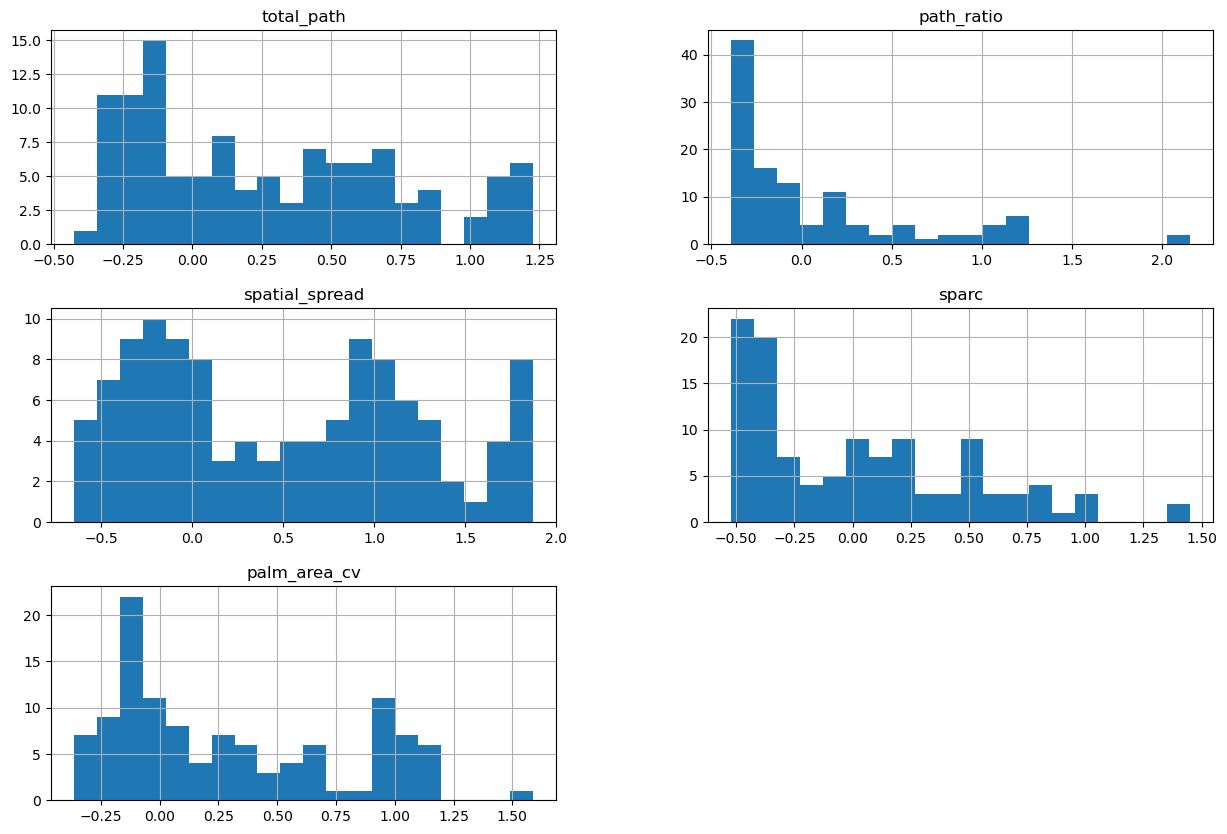

In [62]:
# histogrames of each feat:
profile_df[vocab.feature_cols].hist(bins=20, figsize=(15, 10))

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def identify_consensus_surgemes(profile_df, feature_cols, n_meta_clusters=None):
    """
    Groups the selected centroids from all LOSO folds into 
    consensus 'Meta-SurgeMes'.
    """
    # 1. Extract the coordinates of all selected centroids
    X_meta = profile_df[feature_cols].values
    
    # 2. Determine number of Meta-Clusters (if not provided)
    # Usually, if you have 16 clusters per fold, you might find 
    # 3-6 'consensus' behaviors that actually drive the score.
    if n_meta_clusters is None:
        # Simple heuristic: find the best silhouette score
        best_n = 2
        best_s = -1
        for n in range(2, 8):
            km = KMeans(n_clusters=n, random_state=42).fit(X_meta)
            s = silhouette_score(X_meta, km.labels_)
            if s > best_s:
                best_s = s
                best_n = n
        n_meta_clusters = best_n

    # 3. Fit Meta-Clustering
    meta_km = KMeans(n_clusters=n_meta_clusters, random_state=42)
    profile_df['Meta_Cluster_ID'] = meta_km.fit_transform(X_meta).argmin(axis=1) # Get labels
    
    # 4. Create the 'Consensus Table'
    # This averages the kinematic signatures of each consensus behavior
    consensus_table = profile_df.groupby('Meta_Cluster_ID')[feature_cols].mean()
    
    # 5. Calculate 'Selection Frequency'
    # How many folds out of the total LOSO folds picked this type of behavior?
    # This is a proxy for how 'universal' the behavior is.
    counts = profile_df['Meta_Cluster_ID'].value_counts()
    consensus_table['Fold_Frequency'] = counts / profile_df['Surgeon_Out'].nunique()
    
    return consensus_table, profile_df

In [64]:
consensus_table, annotated_profiles = identify_consensus_surgemes(profile_df, feature_cols=vocab.feature_cols)

In [65]:
consensus_table

,total_path,path_ratio,spatial_spread,sparc,palm_area_cv,Fold_Frequency
Meta_Cluster_ID,,,,,,
0,-0.066918,1.100706,-0.376598,0.129489,0.019093,0.428571
1,0.642072,-0.139469,0.978005,0.530067,0.257662,0.464286
2,-0.047903,-0.112079,0.185582,0.674496,-0.137987,0.464286
3,0.394281,-0.323892,0.918443,-0.415755,-0.138538,1.035714
4,1.097416,-0.340067,1.721282,-0.387555,0.393519,0.535714
5,0.490165,2.128403,-0.098385,0.541848,0.570215,0.071429
6,-0.167863,0.271223,-0.202595,0.093373,0.958907,1.071429


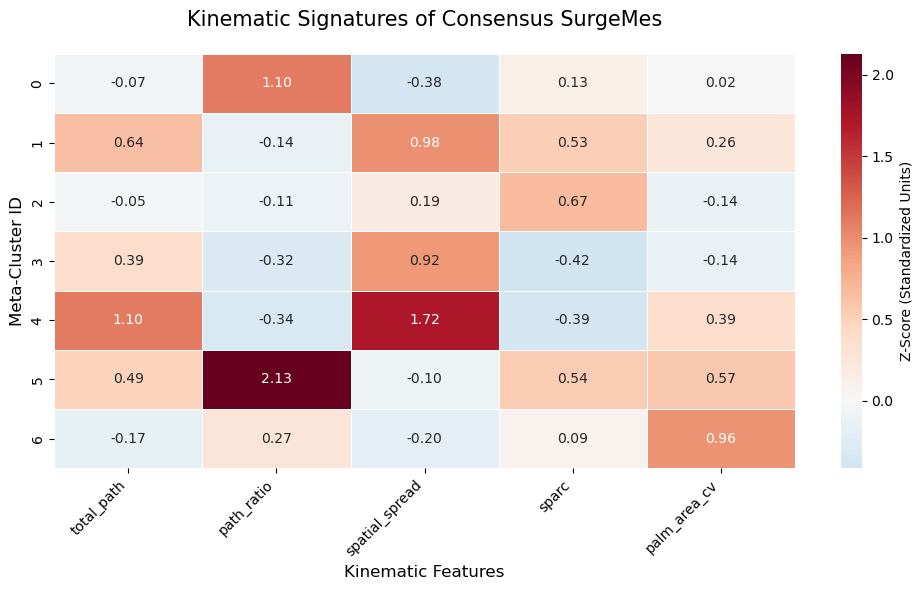

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_consensus_heatmap(consensus_table, feature_cols):
    """
    Plots a heatmap of the kinematic signatures of Consensus SurgeMes.
    """
    # 1. Isolate the kinematic features for the heatmap
    # We exclude 'Fold_Frequency' and 'PR2' for the main colors
    plot_data = consensus_table[feature_cols]
    
    # 2. Setup the figure
    plt.figure(figsize=(10, 6))
    
    # 3. Create Heatmap
    # cmap='RdBu_r' is perfect for Z-scores (Red = High, Blue = Low)
    # center=0 ensures that the "average" is white
    sns.heatmap(
        plot_data, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Z-Score (Standardized Units)'}
    )
    
    plt.title('Kinematic Signatures of Consensus SurgeMes', fontsize=15, pad=20)
    plt.xlabel('Kinematic Features', fontsize=12)
    plt.ylabel('Meta-Cluster ID', fontsize=12)
    
    # Optional: Rotate labels for better fit
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Execution
consensus_table, profile_df = identify_consensus_surgemes(profile_df, vocab.feature_cols)
plot_consensus_heatmap(consensus_table, vocab.feature_cols)

### **Lasso CV directly with all BoWs**

In [67]:
from sklearn.linear_model import LassoCV, ElasticNetCV

vocab = KinematicVocabulary(n_clusters=16, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])

model = ElasticNetCV(alphas=np.logspace(-1, 1, 20))

results_df, stability, profile_df = run_hybrid_vocabulary_loso(
            df_videos=df_pc1_features, 
            df_windows=df_window, 
            primary_features=pc1_features, 
            extra_features=['velocity_corr'], 
            target_col='QRS_Overal', 
            surgeon_col='Participant Number', 
            video_col='video_id', 
            vocab=vocab,
            model=model
)

Running LOSO:   0%|          | 0/28 [00:00<?, ?it/s]

Running LOSO: 100%|██████████| 28/28 [00:26<00:00,  1.04it/s]


=== Hybrid SurgeMe LOSO Summary ===
MAE: 4.9242 ± 3.8202
Spearman R: 0.7410
Overall R2: 0.5517

Top SurgeMe Predictors (Selection Stability):
SurgeMe_0    1.0
SurgeMe_1    1.0
SurgeMe_2    1.0
SurgeMe_3    1.0
SurgeMe_4    1.0
Name: count, dtype: float64
